# Fig. S1B, S1C: Effects of restricting beam movmeent

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from infotaxis import one_target

from scipy import stats

import seaborn as sns

In [2]:
path_fig = Path("../figs")

In [3]:
def load_summary(path_csv, search_type, cr, br, pm, bmr=None):
    if bmr:
        return pd.read_csv(
            path_csv / f"{search_type}_cr{cr}_br{br}_bmr{bmr}_pm{pm:.0e}_pfa{pm:.0e}_summary.csv",
            index_col=0
        )
    else:
        return pd.read_csv(
            path_csv / f"{search_type}_cr{cr}_br{br}_pm{pm:.0e}_pfa{pm:.0e}_summary.csv",
            index_col=0
        )

In [4]:
def get_stats(x, y, print_stats=True):
    stats_dict = dict()
    stats_dict["two-sided"] = stats.mannwhitneyu(x, y, alternative="two-sided")
    stats_dict["less"] = stats.mannwhitneyu(x, y, alternative="less")
    stats_dict["greater"] = stats.mannwhitneyu(x, y, alternative="greater")

    if print_stats:
        print("---------------------------------------------")
        print(f"Samples: default: {len(x):4d}    restrict beam movement: {len(y):4d}")
        print(f"Mean:    default: {np.mean(x):.3f}  restrict beam movement: {np.mean(y):.3f}")
        print(f"Median:  default: {np.median(x):.3f}  restrict beam movement: {np.median(y):.3f}")
        print("")
        print("MWU test")
        print(f" - different: {stats_dict["two-sided"].pvalue:.5f}")
        print(f" - less:      {stats_dict["less"].pvalue:.5f}")
        print(f" - greater:   {stats_dict["greater"].pvalue:.5f}")

    return stats_dict

In [5]:
def bar_violinplot(
    cr, br, bmr, pm_all, alpha=0.65, ping_bins=np.arange(0, 155, 5), print_stats=True
):

    # Get search space grid info
    search_dict = None
    param_echo = {
        str(br): {
            "pm_const": 0.001,
            "pfa_const": 0.001,
        },
    }
    oth = one_target.OneTargetHex(
        search_rule="infotaxis",
        canvas_radius=cr,
        beam_radius=[br],
        target_cube=(0, 0, 0),
        aim_start_cube=(-2, 3, -1),
        param_animal= param_echo,
        param_echo= param_echo,
        search_dict=search_dict
    )

    grid_in_beam = oth.beam_cover_last_cube.shape[0]
    grid_in_space = oth.canvas_cube.shape[0]
    alpha_grid = grid_in_beam / grid_in_space

    # Get colors for plotting
    colors = sns.color_palette("Set2")
    colors_dark = sns.color_palette("Dark2")

    # Plot
    colors = sns.color_palette("Set2")
    colors_dark = sns.color_palette("Dark2")

    fig, axes = plt.subplots(1, len(pm_all), figsize=(6, 3), sharey=True)
    fig.subplots_adjust(wspace=0)  # No space between subplots

    for idx, pm in enumerate(pm_all):

        # Load summary and ph details
        df_x = load_summary(
            path_csv=Path("../simulations/20251027_summary_refined"),
            search_type="infotaxis", cr=cr, br=br, pm=pm
        )
        df_y = load_summary(
            path_csv=Path("../simulations/20251118_summary_refined"),
            search_type="infotaxis", cr=cr, br=br, pm=pm, bmr=bmr
        )

        # Plot only runs with 1 grid left
        x = df_x[df_x["num_grid_left"]==1]["num_pings_2conditions"].values
        y = df_y[df_y["num_grid_left"]==1]["num_pings_2conditions"].values

        # Print statistics
        stats_dict = get_stats(x, y, print_stats)

        # Plotting number of pings to success
        ping_bins = np.arange(0, np.ceil(np.hstack((x, y)).max())+10, 5)

        ax_n = axes[idx]

        x_hist, x_bins = np.histogram(x, bins=ping_bins, density=True)
        y_hist, y_bins = np.histogram(y, bins=ping_bins, density=True)
        x_median = np.median(x)
        y_median = np.median(y)

        bar_x = ax_n.barh(x_bins[:-1], -x_hist, height=np.diff(x_bins), left=0, align="edge", edgecolor="w", color=colors[0], alpha=alpha)
        bar_y = ax_n.barh(y_bins[:-1], y_hist, height=np.diff(x_bins), left=0, align="edge", edgecolor="w", color=colors[2], alpha=alpha)        

        # Get x-axis limits
        xlim = ax_n.get_xlim()
        xlim = np.max([max(xlim), -min(xlim)])
        xlim = xlim + 0.1*np.max(xlim)
        ax_n.set_xlim(-xlim, xlim)
        ax_n.axhline(x_median, xmin=0.0, xmax=0.5, color=colors_dark[0], solid_capstyle="butt", lw=2.5)
        ax_n.axhline(y_median, xmin=0.51, xmax=1, color=colors_dark[2], solid_capstyle="butt", lw=2.5)

        # label sample number
        ax_n.set_xticks([])
        ax_n.set_xticklabels("")
        
        
        # label p-value for alternative="less"
        ax_n.text(
            0.975, 0.93, f"p={stats_dict["less"].pvalue:.0e}",
            ha="right", va="center",
            transform=ax_n.transAxes,
            fontsize=11, 
        )

        ax_n.tick_params(direction='in', which='both')
        if idx != 0:
            if ping_bins[-1] > 200:
                ax_n.set_yticks(ping_bins[::8])
            else:
                ax_n.set_yticks(ping_bins[::4])

        # make title line
        if idx==0: # if first panel
            ax_n.text(
                0.26, 1.015, r"$P_M=P_{FA}$=",
                ha="right", va="bottom",
                transform=ax_n.transAxes,
                fontsize=12,
            )
            ax_n.set_ylabel("Number of pings\nto success", fontsize=12)
        ax_n.set_title(f"{pm}")

    # Add title for the entire figure
    fig.text(0.5, 1.01, fr"$\mathbfit{{\alpha}}$={alpha_grid:.3f}  ($\mathbfit{{r_A}}$={cr}, $\mathbfit{{r_B}}$={br}, $\mathbfit{{r_M}}$={bmr})",
        ha="center", va="center", fontsize=12, fontweight="bold")

   # Add single horizontal legend below all panels
    fig.legend(
        handles=[bar_x, bar_y],
        labels=['Default', 'Restrict beam aim movement'],
        loc='lower center',
        ncol=2,
        bbox_to_anchor=(0.5, -0.03),
        # frameon=False,
        fontsize=11
    )

    # plt.tight_layout(pad=0)
    plt.show()

    return fig

## Number of pings until finding 1 grid

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 1
---------------------------------------------
Samples: default: 1000    restrict beam movement: 1000
Mean:    default: 10.487  restrict beam movement: 10.614
Median:  default: 10.000  restrict beam movement: 10.000

MWU test
 - different: 0.73544
 - less:      0.63231
 - greater:   0.36772
---------------------------------------------
Samples: default: 1000    restrict beam movement: 1000
Mean:    default: 12.760  restrict beam movement: 13.125
Median:  default: 12.000  restrict beam movement: 12.000

MWU test
 - different: 0.46195
 - less:      0.23098
 - greater:   0.76905
---------------------------------------------
Samples: default: 1000    restrict beam movement: 1000
Mean:    default: 14.806  restrict beam movement: 15.481
Median:  default: 14.000  restrict beam movement: 14.000

MWU test
 - different: 0.18271
 - less:      0.09135
 - greater:   0.90866
------

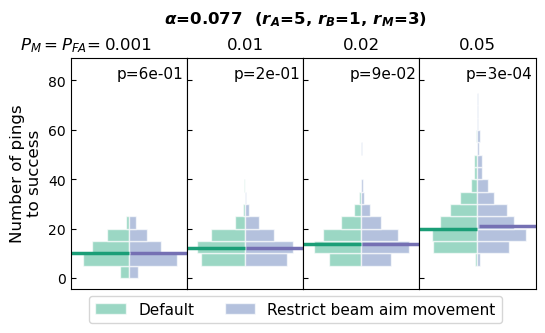

In [6]:
cr = 5
br = 1
bmr = 3
pm_all = [0.001, 0.01, 0.02, 0.05]

fig = bar_violinplot(cr, br, bmr, pm_all, print_stats=True)

fig.savefig(path_fig / f"fig_S1B_infotaxis_restrict_beam_movement_cmp_cr{cr}_br{br}_bmr{bmr}.png", dpi=300, bbox_inches="tight")

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 1
---------------------------------------------
Samples: default: 1000    restrict beam movement:  998
Mean:    default: 10.487  restrict beam movement: 11.599
Median:  default: 10.000  restrict beam movement: 11.000

MWU test
 - different: 0.00936
 - less:      0.00468
 - greater:   0.99532
---------------------------------------------
Samples: default: 1000    restrict beam movement: 1000
Mean:    default: 12.760  restrict beam movement: 14.272
Median:  default: 12.000  restrict beam movement: 13.000

MWU test
 - different: 0.00050
 - less:      0.00025
 - greater:   0.99975
---------------------------------------------
Samples: default: 1000    restrict beam movement: 1000
Mean:    default: 14.806  restrict beam movement: 16.773
Median:  default: 14.000  restrict beam movement: 15.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
------

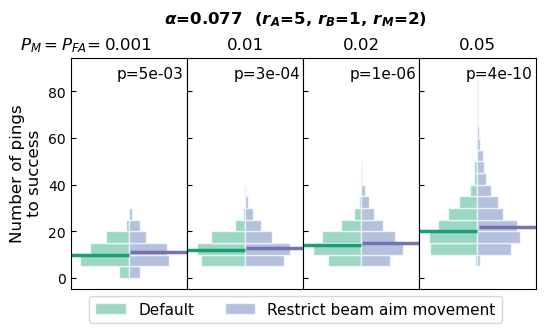

In [7]:
cr = 5
br = 1
bmr = 2
pm_all = [0.001, 0.01, 0.02, 0.05]

fig = bar_violinplot(cr, br, bmr, pm_all, print_stats=True)

fig.savefig(path_fig / f"fig_S1B_infotaxis_restrict_beam_movement_cmp_cr{cr}_br{br}_bmr{bmr}.png", dpi=300, bbox_inches="tight")

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 1
---------------------------------------------
Samples: default: 1000    restrict beam movement:  989
Mean:    default: 29.434  restrict beam movement: 30.282
Median:  default: 28.000  restrict beam movement: 27.000

MWU test
 - different: 0.95914
 - less:      0.52046
 - greater:   0.47957
---------------------------------------------
Samples: default: 1000    restrict beam movement: 1000
Mean:    default: 33.968  restrict beam movement: 36.002
Median:  default: 33.000  restrict beam movement: 32.000

MWU test
 - different: 0.23412
 - less:      0.11706
 - greater:   0.88295
---------------------------------------------
Samples: default: 1000    restrict beam movement: 1000
Mean:    default: 38.191  restrict beam movement: 43.075
Median:  default: 36.000  restrict beam movement: 38.000

MWU test
 - different: 0.00064
 - less:      0.00032
 - greater:   0.99968
------

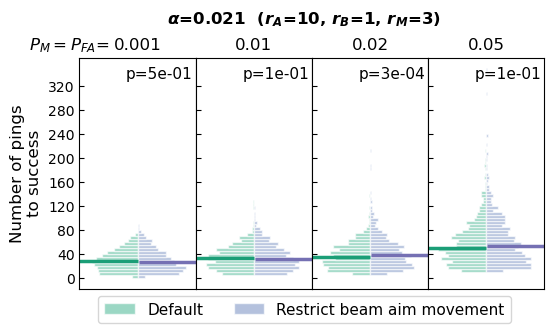

In [8]:
cr = 10
br = 1
bmr = 3
pm_all = [0.001, 0.01, 0.02, 0.05]

fig = bar_violinplot(cr, br, bmr, pm_all, print_stats=True)

fig.savefig(path_fig / f"fig_S1C_infotaxis_restrict_beam_movement_cmp_cr{cr}_br{br}_bmr{bmr}.png", dpi=300, bbox_inches="tight")

Initial beam aim is given, but not initial beam radius.
Set initial beam radius to the largest of beam radius choices: 1
---------------------------------------------
Samples: default: 1000    restrict beam movement:  794
Mean:    default: 29.434  restrict beam movement: 30.144
Median:  default: 28.000  restrict beam movement: 26.000

MWU test
 - different: 0.44586
 - less:      0.77710
 - greater:   0.22293
---------------------------------------------
Samples: default: 1000    restrict beam movement:  989
Mean:    default: 33.968  restrict beam movement: 41.108
Median:  default: 33.000  restrict beam movement: 34.000

MWU test
 - different: 0.00010
 - less:      0.00005
 - greater:   0.99995
---------------------------------------------
Samples: default: 1000    restrict beam movement:  998
Mean:    default: 38.191  restrict beam movement: 46.988
Median:  default: 36.000  restrict beam movement: 40.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
------

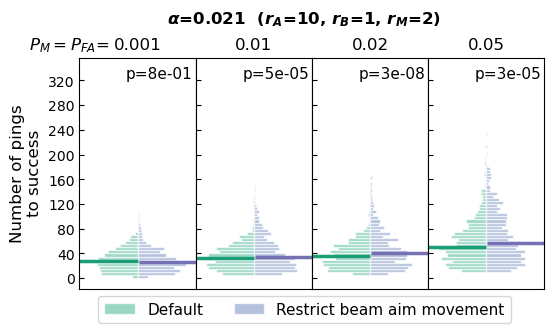

In [9]:
cr = 10
br = 1
bmr = 2
pm_all = [0.001, 0.01, 0.02, 0.05]

fig = bar_violinplot(cr, br, bmr, pm_all, print_stats=True)

fig.savefig(path_fig / f"fig_S1C_infotaxis_restrict_beam_movement_cmp_cr{cr}_br{br}_bmr{bmr}.png", dpi=300, bbox_inches="tight")